In [3]:
import numpy as np
import pandas as pd

Preparing for <br>
How do students transition between groups of learning elements based on their gaze and interaction behavior?

In [4]:
interaction_df = pd.read_csv("interaction_clean_final.csv")
gaze_episodes = pd.read_csv("gaze_episodes_final.csv")
clusters = pd.read_csv("clustered_element_analysis.csv")

Total gaze episodes: 25667
 threshold_seconds  episodes_removed  episodes_retained  percent_removed  percent_retained
              0.00                 0              25667             0.00            100.00
              0.05              8751              16916            34.09             65.91
              0.10              9684              15983            37.73             62.27
              0.15             12394              13273            48.29             51.71
              0.20             13061              12606            50.89             49.11
              0.25             14573              11094            56.78             43.22
              0.30             15349              10318            59.80             40.20
              0.35             16321               9346            63.59             36.41
              0.40             16794               8873            65.43             34.57
              0.45             17588               8079        

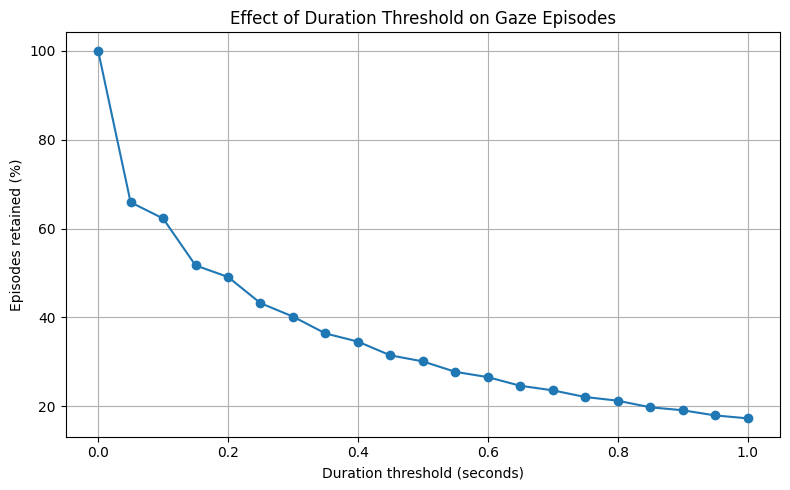

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Gaze episode duration distribution
# ---------------------------------------------------------

duration = gaze_episodes["gaze_duration_seconds"].dropna()

print("Total gaze episodes:", len(duration))

# ---------------------------------------------------------
# Candidate thresholds
# ---------------------------------------------------------

thresholds = np.arange(0.00, 1.01, 0.05)

threshold_analysis = pd.DataFrame({
    "threshold_seconds": thresholds
})

threshold_analysis["episodes_removed"] = [
    (duration < t).sum()
    for t in thresholds
]

threshold_analysis["episodes_retained"] = [
    (duration >= t).sum()
    for t in thresholds
]

threshold_analysis["percent_removed"] = (
    threshold_analysis["episodes_removed"]
    / len(duration) * 100
).round(2)

threshold_analysis["percent_retained"] = (
    threshold_analysis["episodes_retained"]
    / len(duration) * 100
).round(2)

print(threshold_analysis.to_string(index=False))


# ---------------------------------------------------------
# Duration percentiles
# ---------------------------------------------------------

print("\nDuration percentiles:")

print(
    duration.quantile(
        [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)


# ---------------------------------------------------------
# Visualise effect of threshold
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_analysis["threshold_seconds"],
    threshold_analysis["percent_retained"],
    marker="o"
)

plt.xlabel("Duration threshold (seconds)")
plt.ylabel("Episodes retained (%)")
plt.title("Effect of Duration Threshold on Gaze Episodes")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Element → cluster mapping
cluster_map = (
    clusters[["aoi", "cluster"]]
    .drop_duplicates()
    .rename(columns={"aoi": "element"})
)

# ---------------------------------------------------------
# GAZE DATA
# ---------------------------------------------------------

gaze = gaze_episodes[
    gaze_episodes["gaze_duration_seconds"] >= 0.1
].copy()

gaze = gaze.rename(columns={"aoi": "element"})

gaze = gaze.merge(
    cluster_map,
    on="element",
    how="left"
)

gaze["verb"] = "Gazed"

gaze["event_timestamp"] = pd.to_datetime(
    gaze["gaze_start"],
    errors="coerce",
    utc=True
)

gaze["cluster_activity"] = (
    "Gazed at element from Cluster "
    + gaze["cluster"].astype("Int64").astype(str)
)

gaze["element_activity"] = (
    "Gazed "
    + gaze["element"].astype(str)
)

gaze["gaze_cluster_activity"] = (
    "Gazed element from Cluster "
    + gaze["cluster"].astype("Int64").astype(str)
)

# ---------------------------------------------------------
# INTERACTION DATA
# ---------------------------------------------------------

interaction = interaction_df.merge(
    cluster_map,
    on="element",
    how="left"
)

interaction["event_timestamp"] = pd.to_datetime(
    interaction["interaction_timestamp"],
    errors="coerce",
    utc=True
)

interaction["cluster_activity"] = (
    interaction["verb"].astype(str)
    + " element from Cluster "
    + interaction["cluster"].astype("Int64").astype(str)
)

interaction["element_activity"] = (
    interaction["verb"].astype(str)
    + " "
    + interaction["element"].astype(str)
)

interaction["non_gaze_cluster_activity"] = (
    "Non-Gaze Interaction with element from Cluster "
    + interaction["cluster"].astype("Int64").astype(str)
)

# ---------------------------------------------------------
# GAZE + INTERACTION DATA
# ---------------------------------------------------------

gaze_interaction_df = pd.concat(
    [gaze, interaction],
    ignore_index=True,
    sort=False
)

# Generalize ALL event types:
# Gazed, Clicked, timespend, Answered, etc.
gaze_interaction_df["interaction_cluster_activity"] = (
    "Interacted with element from Cluster "
    + gaze_interaction_df["cluster"].astype("Int64").astype(str)
)

# ---------------------------------------------------------
# INTERACTION-ONLY DATA
# ---------------------------------------------------------

interaction_only_df = interaction.copy()

# ---------------------------------------------------------
# SORT CHRONOLOGICALLY
# ---------------------------------------------------------

gaze_interaction_df = (
    gaze_interaction_df
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

interaction_only_df = (
    interaction_only_df
    .sort_values(
        ["user_id", "event_timestamp"]
    )
    .reset_index(drop=True)
)

In [4]:
gaze_interaction_df = gaze_interaction_df[
    [
        "user_id",
        "event_timestamp",
        "verb",
        "element",
        "elementType",
        "cluster_activity",
        "element_activity",
        "interaction_cluster_activity",
        "gaze_cluster_activity"
    ]
].copy()

interaction_only_df = interaction_only_df[
    [
        "user_id",
        "event_timestamp",
        "verb",
        "element",
        "elementType",
        "cluster_activity",
        "element_activity",
        "non_gaze_cluster_activity"
    ]
].copy()

In [5]:
gaze_interaction_df.head(5)

,user_id,event_timestamp,verb,element,elementType,cluster_activity,element_activity,interaction_cluster_activity,gaze_cluster_activity
0,69142eb4410888a7b66fa988,2025-11-12 07:09:29.976000+00:00,Clicked,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,Clicked element from Cluster 1,Clicked 1🟦 [Introduction: the robot 'Robbie' a...,Interacted with element from Cluster 1,NaN
1,69142eb4410888a7b66fa988,2025-11-12 07:09:30.679000+00:00,Gazed,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,Gazed at element from Cluster 1,Gazed 1🟦 [Introduction: the robot 'Robbie' and...,Interacted with element from Cluster 1,Gazed element from Cluster 1
2,69142eb4410888a7b66fa988,2025-11-12 07:09:32.420000+00:00,Gazed,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,Gazed at element from Cluster 1,Gazed 1🟦【導入部：ロボット「ロビー」とグロリア】,Interacted with element from Cluster 1,Gazed element from Cluster 1
3,69142eb4410888a7b66fa988,2025-11-12 07:09:34.877000+00:00,Gazed,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,Gazed at element from Cluster 1,Gazed 1🟦 [Introduction: the robot 'Robbie' and...,Interacted with element from Cluster 1,Gazed element from Cluster 1
4,69142eb4410888a7b66fa988,2025-11-12 07:09:35.531000+00:00,Clicked,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,Clicked element from Cluster 1,Clicked 1🟦【導入部：ロボット「ロビー」とグロリア】,Interacted with element from Cluster 1,NaN


In [6]:
interaction_only_df

,user_id,event_timestamp,verb,element,elementType,cluster_activity,element_activity,non_gaze_cluster_activity
0,69142eb4410888a7b66fa988,2025-11-12 07:09:29.976000+00:00,Clicked,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,Clicked element from Cluster 1,Clicked 1🟦 [Introduction: the robot 'Robbie' a...,Non-Gaze Interaction with element from Cluster 1
1,69142eb4410888a7b66fa988,2025-11-12 07:09:35.531000+00:00,Clicked,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,Clicked element from Cluster 1,Clicked 1🟦【導入部：ロボット「ロビー」とグロリア】,Non-Gaze Interaction with element from Cluster 1
2,69142eb4410888a7b66fa988,2025-11-12 07:10:54.827000+00:00,Clicked,3🟩 [Grief after the loss],instruction,Clicked element from Cluster 2,Clicked 3🟩 [Grief after the loss],Non-Gaze Interaction with element from Cluster 2
3,69142eb4410888a7b66fa988,2025-11-12 07:14:34.788000+00:00,timespend,Q2 - Why was Gloria sad?,text,timespend element from Cluster 0,timespend Q2 - Why was Gloria sad?,Non-Gaze Interaction with element from Cluster 0
4,69142eb4410888a7b66fa988,2025-11-12 07:14:34.789000+00:00,Answered,Q2 - Why was Gloria sad?,text,Answered element from Cluster 0,Answered Q2 - Why was Gloria sad?,Non-Gaze Interaction with element from Cluster 0
...,...,...,...,...,...,...,...,...
468,69142ee2410888a7b66fabd0,2025-11-12 07:15:42.967000+00:00,Clicked,2🟧【母親の不安と別れ】,instruction,Clicked element from Cluster 1,Clicked 2🟧【母親の不安と別れ】,Non-Gaze Interaction with element from Cluster 1
469,69142ee2410888a7b66fabd0,2025-11-12 07:15:45.321000+00:00,Clicked,3🟩【喪失による喪失感】,instruction,Clicked element from Cluster 1,Clicked 3🟩【喪失による喪失感】,Non-Gaze Interaction with element from Cluster 1
470,69142ee2410888a7b66fabd0,2025-11-12 07:15:46.787000+00:00,Clicked,3🟩【喪失による喪失感】,instruction,Clicked element from Cluster 1,Clicked 3🟩【喪失による喪失感】,Non-Gaze Interaction with element from Cluster 1
471,69142ee2410888a7b66fabd0,2025-11-12 07:15:48.169000+00:00,Clicked,3🟩【喪失による喪失感】,instruction,Clicked element from Cluster 1,Clicked 3🟩【喪失による喪失感】,Non-Gaze Interaction with element from Cluster 1


In [7]:
len(interaction_only_df), len(gaze_interaction_df)

(473, 11567)

In [8]:
interaction_only_df.to_csv("interaction_for_spm.csv", index=False)
gaze_interaction_df.to_csv("gaze_interaction_for_spm.csv", index=False)

### Data Preparation for TNA

Gaze episodes and interaction events were combined, chronologically ordered per learner, and mapped to the K-Means cluster of their corresponding learning elements. These sequences were used for TNA and sequential pattern mining.